In [1]:
%load_ext autoreload
%autoreload 2 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
from Preprocess import preprocess_data
from Preprocess import preprocess_data_window
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
import optuna
import shap

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time,
    data_orig,
    n_previous_events=20
)

X shape:  (2822, 126)
y shape:  (2822,)


In [4]:
# Random Forest Implementation with tuning 
#The tuning actually performs more poorly than the basic implementation 
def objective(trial):
  random_forest = RandomForestRegressor(
    n_estimators=trial.suggest_int("n_estimators",500,1200),
    random_state=42,
    bootstrap = True, 
    max_depth=trial.suggest_int("max_depth",10,30), 
    min_samples_leaf=trial.suggest_int("min_samples_leaf",2,10),
    min_samples_split=trial.suggest_int("min_samples_split",5,20),
    max_features= trial.suggest_categorical("max_features",["sqrt", "log2", 0.3,0.5,0.7]),
    n_jobs=-1,
    oob_score=True
  )
  random_forest.fit(
      X_train, y_train)
  return random_forest.oob_score_

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
random_forest =RandomForestRegressor(
    bootstrap=True,
    **optimal_params,
    random_state=42,
)
random_forest.fit(X_train, y_train)
random_forest_prediction = random_forest.predict(X_test)
random_forest_RMSE = root_mean_squared_error(y_val, random_forest_prediction)

print("Random Forest RMSE:" , random_forest_RMSE)

Random_Forest_MAE = mean_absolute_error(y_test, random_forest_prediction)
print("Random Forest Error:",Random_Forest_MAE)

[I 2026-03-09 12:41:50,559] A new study created in memory with name: no-name-e7c7cebc-c5d2-4bf1-b2eb-4cb0e24ba136
[I 2026-03-09 12:41:53,034] Trial 0 finished with value: 0.32279626564929975 and parameters: {'n_estimators': 762, 'max_depth': 29, 'min_samples_leaf': 8, 'min_samples_split': 14, 'max_features': 0.5}. Best is trial 0 with value: 0.32279626564929975.
[I 2026-03-09 12:41:56,599] Trial 1 finished with value: 0.31997249672616257 and parameters: {'n_estimators': 996, 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 18, 'max_features': 0.7}. Best is trial 1 with value: 0.31997249672616257.
[I 2026-03-09 12:41:59,161] Trial 2 finished with value: 0.32728466472028694 and parameters: {'n_estimators': 802, 'max_depth': 16, 'min_samples_leaf': 7, 'min_samples_split': 7, 'max_features': 0.5}. Best is trial 1 with value: 0.31997249672616257.
[I 2026-03-09 12:42:02,740] Trial 3 finished with value: 0.3394281826928194 and parameters: {'n_estimators': 860, 'max_depth': 22, 'm

Optimal Parameters: {'n_estimators': 1042, 'max_depth': 18, 'min_samples_leaf': 10, 'min_samples_split': 5, 'max_features': 'log2'}
Random Forest RMSE: 20674.062139438563
Random Forest Error: 14768.62146322624


In [6]:
# Random Forest Implementation 

random_forest = RandomForestRegressor( 
    n_estimators=1000, 
    random_state=42,
    #bootstrap = True, 
    #max_depth=20, 
    #min_samples_leaf=5,
    #min_samples_split=10,
    #max_features="sqrt",
    #n_jobs=-1
)
random_forest.fit(X_train, y_train)

random_forest_prediction = random_forest.predict(X_test)
random_forest_RMSE = root_mean_squared_error(y_val, random_forest_prediction)

print("Random Forest RMSE:" , random_forest_RMSE)

Random_Forest_MAE = mean_absolute_error(y_test, random_forest_prediction)
print("Random Forest Error:" , Random_Forest_MAE)

Random Forest RMSE: 21849.362620544856
Random Forest Error: 12147.873079646017


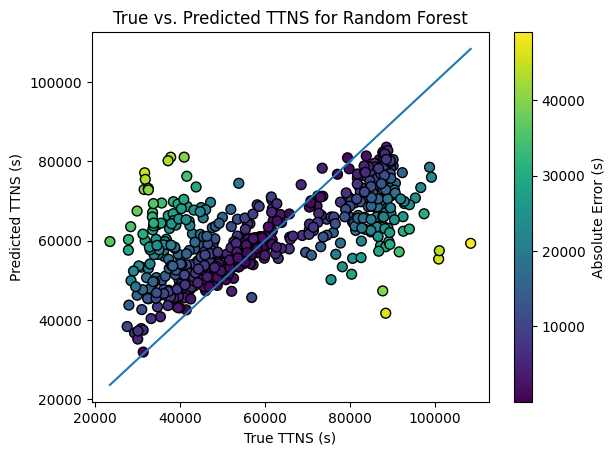

In [7]:
#For graph, taken directly from cat, needs to be updated for this

absolute_error_secs_RF = np.abs(random_forest_prediction - y_test)

plt.figure()
plt.scatter(y_test, random_forest_prediction, c=absolute_error_secs_RF, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Random Forest")
plt.show()

100%|===================| 979/980 [07:49<00:00]        

RF Boost Drivers: tide_height    3204.241691
form_fac       2615.996961
time_since     2397.940126
slip_size      2082.065428
tide_deriv     1493.463406
high_t_evt     1023.238707
dtype: float64


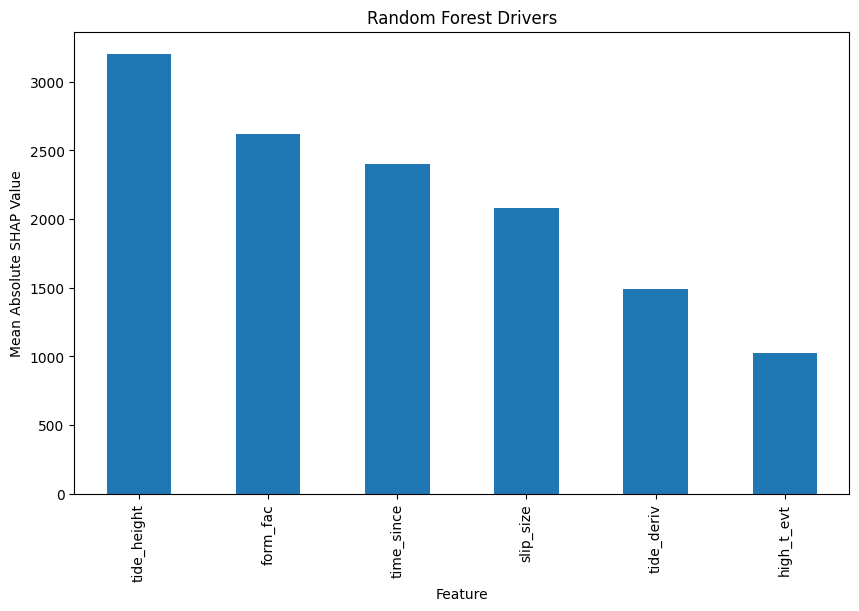

In [ ]:
# Driving parameters for RF

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_RF = shap.TreeExplainer(random_forest, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_RF = explainer_RF.shap_values(X_shap, check_additivity=False)

RF_imp = pd.Series(np.abs(shap_values_RF).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("RF Boost Drivers:", RF_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
RF_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Random Forest Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()